In [1]:
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from useful_functions import *

In [2]:
spectra_data    = fits.open('/Users/hyp0515/data/0715_Spring_BGS_ALL_trimmed.fits')
color_data      = fits.open('/Users/hyp0515/data/0715_Spring_half_BGS_BRIGHT_catalog_with_Flux.fits')

SPECTRA = Spectrum(spectra_data, color_data)
FIT     = FitSpectrum()


blue_crit   = SPECTRA.color_criteria(blue=True, exclude=False)
qso_crit    = SPECTRA.subtype_criteria(subtype='QSO', exclude=True)

SPECTRA.subset(criteria=blue_crit & qso_crit)
SPECTRA.shrink_dataset(5)
SPECTRA.stack_data()
SPECTRA.mask_bad()

In [3]:
SPECTRA = FIT.shift_to_rest_frame(SPECTRA)

In [4]:
idx = np.random.choice(SPECTRA.n_spectra, size=1, replace=False)[0]
id = SPECTRA.targetID[idx]
id = 39627758061489112
idx = SPECTRA.id2index(id)

In [5]:
print(SPECTRA.targetID[idx])
print(image_link(SPECTRA.RA[idx], SPECTRA.DEC[idx]))
print(spectrum_link(SPECTRA.targetID[idx]))

39627758061489112
https://www.legacysurvey.org/viewer?ra=210.63615023373038&dec=-1.2693183495249618&layer=ls-dr10-grz&zoom=14
https://www.legacysurvey.org/viewer/desi-spectrum/dr1/targetid39627758061489112


# Fit with dz, dlam1, dlam2

In [6]:
params_dlam_2comp, (combine_lam, combine_flux, combine_sigma), seperation = FIT.fit_onhs_dlam(SPECTRA, id=id, two_component=True)
print(f'dz: {params_dlam_2comp["dz"]}')

conti_1, conti_2 = params_dlam_2comp['conti_params']
conti_dlam_2comp = np.concatenate([model(combine_lam[:seperation], conti_parms=conti_1), model(combine_lam[seperation:], conti_parms=conti_2)])
combine_flux_dlam_2comp = combine_flux - conti_dlam_2comp

left_comp_dlam = np.concatenate([model(combine_lam[:seperation], gaussian_parms=params_dlam_2comp['left_comp'][:2]), model(combine_lam[seperation:], gaussian_parms=params_dlam_2comp['left_comp'][2:])])
right_comp_dlam = np.concatenate([model(combine_lam[:seperation], gaussian_parms=params_dlam_2comp['right_comp'][:2]), model(combine_lam[seperation:], gaussian_parms=params_dlam_2comp['right_comp'][2:])])
combine_2comp_dlam = left_comp_dlam + right_comp_dlam

chisq_dlam_2comp = np.sum(((combine_flux_dlam_2comp - combine_2comp_dlam)/combine_sigma)**2)
print(f'Chi-sq dlam 2 comp: {chisq_dlam_2comp}')


chisq_dlam_2comp = np.sum(((combine_flux_dlam_2comp - combine_2comp_dlam)/combine_sigma)**2)
dof_2comp       = len(combine_flux) - 19   # 9 + 7*2 - 4(conti; not relevant to F-test)

dz: -0.0002659057177640478
Chi-sq dlam 2 comp: 493.44905964083193


# Fit with dz

In [7]:
params_dlam_1comp, (combine_lam, combine_flux, combine_sigma), seperation = FIT.fit_onhs_dlam(SPECTRA, id=id, two_component=False)
print(f'dz: {params_dlam_1comp["dz"]}')

conti_1, conti_2 = params_dlam_1comp['conti_params']
conti_dlam_1comp = np.concatenate([model(combine_lam[:seperation], conti_parms=conti_1), model(combine_lam[seperation:], conti_parms=conti_2)])
combine_flux_dlam_1comp = combine_flux - conti_dlam_1comp
gaussian_comp = np.concatenate([model(combine_lam[:seperation], gaussian_parms=params_dlam_1comp['gaussian_params']), model(combine_lam[seperation:], gaussian_parms=params_dlam_1comp['gaussian_params'])])
combine_1comp_dlam = gaussian_comp

chisq_dlam_1comp = np.sum(((combine_flux_dlam_1comp - combine_1comp_dlam)/combine_sigma)**2)
print(f'Chi-sq dlam 1 comp: {chisq_dlam_1comp}')

criteria = 3 * combine_sigma
count = 0
for comp in params_dlam_1comp['gaussian_params']:
    amp = comp[0]
    l0 = comp[1]
    
    l0_idx = np.searchsorted(combine_lam, l0)

    if amp > criteria[l0_idx]:
        count += 1
    else:
        continue
if count >= 2:
    print('yes')
else:
    print('no')
    
dof_1comp       = len(combine_flux) - 9   # 6 + 7 - 4(conti; not relevant to F-test)
F_stat = ((chisq_dlam_1comp - chisq_dlam_2comp) / (dof_1comp - dof_2comp)) / (chisq_dlam_2comp / dof_2comp)
p_value = 1 - f.cdf(F_stat, dof_1comp - dof_2comp, dof_2comp)

print(p_value)

dz: -4.572307174907715e-06
Chi-sq dlam 1 comp: 826.5318201050169
yes
1.1102230246251565e-16


# Fit with dz1, dz2

In [8]:
params_dz_free, (combine_lam, combine_flux, combine_sigma), seperation = FIT.fit_onhs_dz(SPECTRA, id=id, two_component=True, w_dz=False)
print(f'dz: {params_dz_free["dz"]}')

conti_1, conti_2 = params_dz_free['conti_params']
conti = np.concatenate([model(combine_lam[:seperation], conti_parms=conti_1), model(combine_lam[seperation:], conti_parms=conti_2)])
combine_flux_dz = combine_flux - conti

left_comp_dz_free = np.concatenate([model(combine_lam[:seperation], gaussian_parms=params_dz_free['left_comp'][:2]), model(combine_lam[seperation:], gaussian_parms=params_dz_free['left_comp'][2:])])
right_comp_dz_free = np.concatenate([model(combine_lam[:seperation], gaussian_parms=params_dz_free['right_comp'][:2]), model(combine_lam[seperation:], gaussian_parms=params_dz_free['right_comp'][2:])])
combine_2comp_dz_free = left_comp_dz_free + right_comp_dz_free

chisq_dz_free = np.sum(((combine_flux_dz - combine_2comp_dz_free)/combine_sigma)**2)
print(f'Chi-sq dz free: {chisq_dz_free}')


left_area = np.sum(left_comp_dz_free)
right_area = np.sum(right_comp_dz_free)
dz1, dz2 = params_dz_free['dz']
dz_centroid = (dz2*left_area + dz1*right_area)/(left_area+right_area)
print(f'dz_centroid: {dz_centroid}')


dz: (np.float64(0.00016746820238619286), np.float64(-0.00027333552162214645))
Chi-sq dz free: 485.9550544529393
dz_centroid: 8.485341287749407e-06


# Fit with dz, dz1, dz2

In [9]:

params_dz_fix, (combine_lam, combine_flux, combine_sigma), seperation = FIT.fit_onhs_dz(SPECTRA, id=id, two_component=True, w_dz=True)
print(f'dz: {params_dz_fix["dz"]}')
print(f'dz1: {params_dz_fix["dlam"][0]}, dz2: {params_dz_fix["dlam"][1]}')
conti_1, conti_2 = params_dz_fix['conti_params']
conti = np.concatenate([model(combine_lam[:seperation], conti_parms=conti_1), model(combine_lam[seperation:], conti_parms=conti_2)])
combine_flux_dz = combine_flux - conti

left_comp_dz_fixed = np.concatenate([model(combine_lam[:seperation], gaussian_parms=params_dz_fix['left_comp'][:2]), model(combine_lam[seperation:], gaussian_parms=params_dz_fix['left_comp'][2:])])
right_comp_dz_fixed = np.concatenate([model(combine_lam[:seperation], gaussian_parms=params_dz_fix['right_comp'][:2]), model(combine_lam[seperation:], gaussian_parms=params_dz_fix['right_comp'][2:])])
combine_2comp_dz_fixed = left_comp_dz_fixed + right_comp_dz_fixed

chisq_dz_fixed = np.sum(((combine_flux_dz - combine_2comp_dz_fixed)/combine_sigma)**2)
print(f'Chi-sq dz fixed: {chisq_dz_fixed}')


dz: 5.9699026136294726e-05
dz1: 0.00013275126570638912, dz2: -0.00030920174637624943
Chi-sq dz fixed: 483.63795083299146


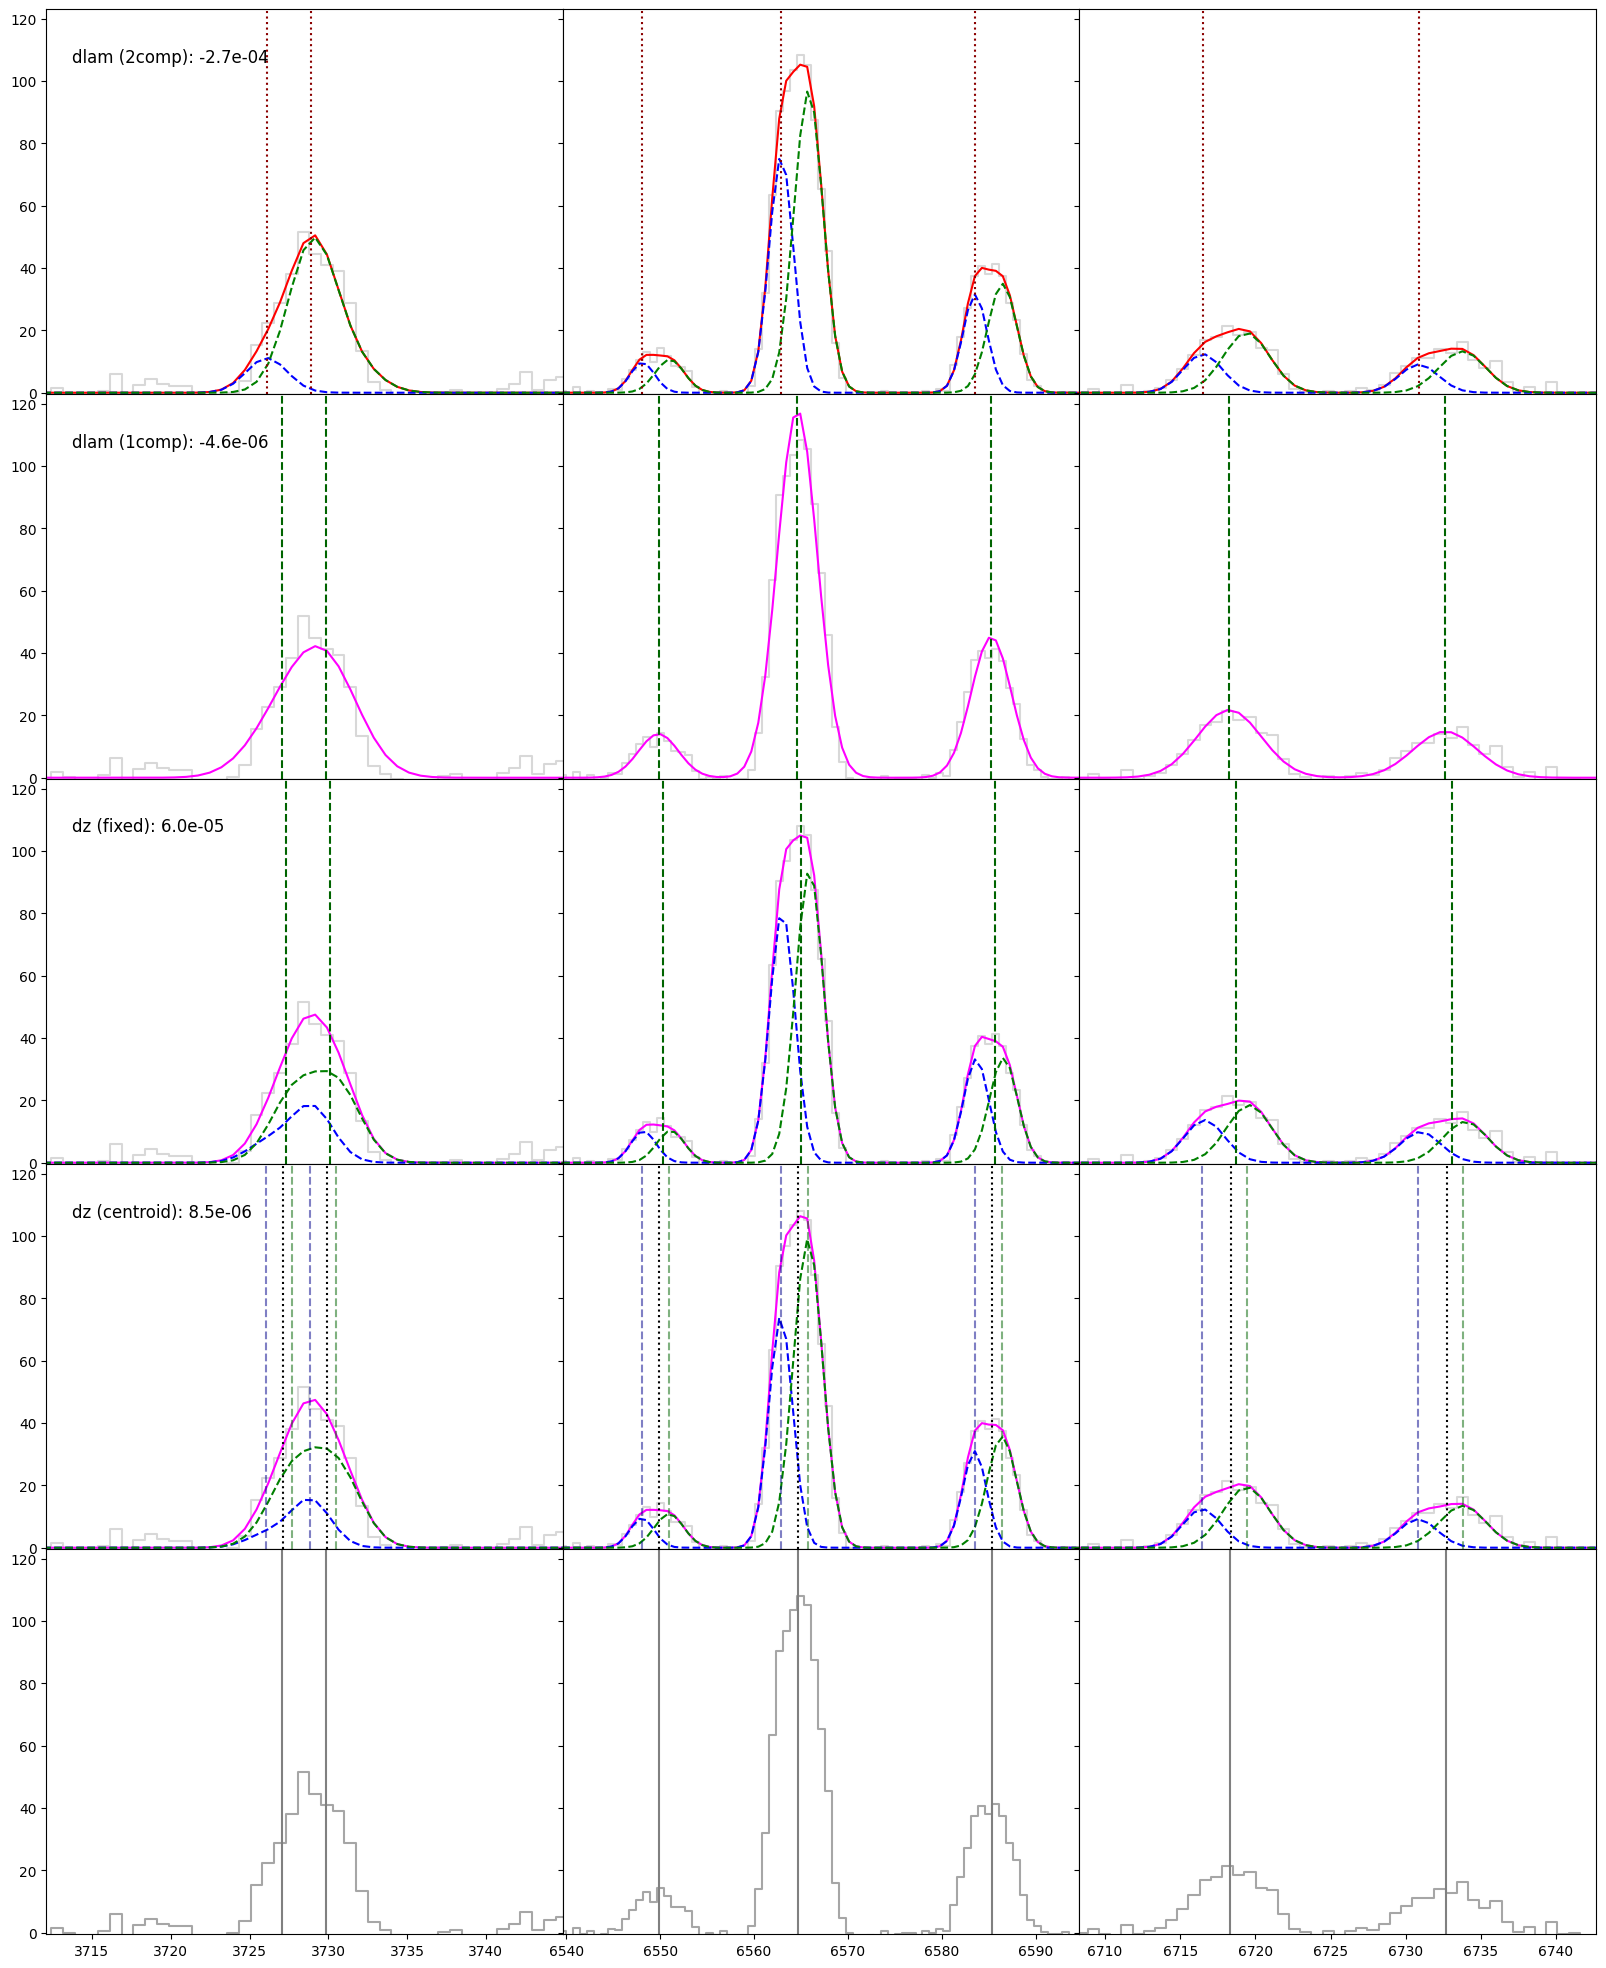

In [10]:

fig, axes = plt.subplots(5, 3, figsize=(20, 25), sharey=True)
plt.subplots_adjust(hspace=0.0, wspace=0.00)


# dlam 2 comp
ax = axes[0, :]
ax[0].text(0.05, 0.9, f'dlam (2comp): {params_dlam_2comp["dz"]:.1e}', transform=ax[0].transAxes, fontsize=12, verticalalignment='top')
for i in range(3):
    ax[i].step(combine_lam, combine_flux_dlam_2comp, label='Observed', where='mid', color='gray', alpha=0.3)
    ax[i].plot(combine_lam, combine_2comp_dlam, label='Fitted Model', color='red')
    ax[i].plot(combine_lam, left_comp_dlam, label='Left Component', color='blue', linestyle='--')
    ax[i].plot(combine_lam, right_comp_dlam, label='Right Component', color='green', linestyle='--')
    for l0 in [*lines_vac['OII'], *lines_vac['Halpha'], *lines_vac['NII'], *lines_vac['SII']]:
        ax[i].axvline(l0*(1+params_dlam_2comp['dz']), color='darkred', linestyle=':', alpha=1)

# dlam 1 comp
ax = axes[1, :]
ax[0].text(0.05, 0.9, f'dlam (1comp): {params_dlam_1comp["dz"]:.1e}', transform=ax[0].transAxes, fontsize=12, verticalalignment='top')
for i in range(3):
    ax[i].step(combine_lam, combine_flux_dlam_1comp, label='Observed', where='mid', color='gray', alpha=0.3)
    ax[i].plot(combine_lam, combine_1comp_dlam, label='Fitted Model', color='magenta')
    for l0 in [*lines_vac['OII'], *lines_vac['Halpha'], *lines_vac['NII'], *lines_vac['SII']]:
        ax[i].axvline(l0*(1+params_dlam_1comp['dz']), color='darkgreen', linestyle='--', alpha=1)


# dz fixed
ax = axes[2, :]
ax[0].text(0.05, 0.9, f'dz (fixed): {params_dz_fix["dz"]:.1e}', transform=ax[0].transAxes, fontsize=12, verticalalignment='top')
for i in range(3):
    ax[i].step(combine_lam, combine_flux_dz, label='Observed', where='mid', color='gray', alpha=0.3)
    ax[i].plot(combine_lam, combine_2comp_dz_fixed, label='Fitted Model', color='magenta')
    ax[i].plot(combine_lam, left_comp_dz_fixed, label='Left Component', color='blue', linestyle='--')
    ax[i].plot(combine_lam, right_comp_dz_fixed, label='Right Component', color='green', linestyle='--')
    for l0 in [*lines_vac['OII'], *lines_vac['Halpha'], *lines_vac['NII'], *lines_vac['SII']]:
        ax[i].axvline(l0*(1+params_dz_fix['dz']), color='darkgreen', linestyle='--', alpha=1)

# dz free
ax = axes[3, :]
ax[0].text(0.05, 0.9, f'dz (centroid): {dz_centroid:.1e}', transform=ax[0].transAxes, fontsize=12, verticalalignment='top')
for i in range(3):
    ax[i].step(combine_lam, combine_flux_dz, label='Observed', where='mid', color='gray', alpha=0.3)
    ax[i].plot(combine_lam, combine_2comp_dz_free, label='Fitted Model', color='magenta')
    ax[i].plot(combine_lam, left_comp_dz_free, label='Left Component', color='blue', linestyle='--')
    ax[i].plot(combine_lam, right_comp_dz_free, label='Right Component', color='green', linestyle='--')
    for l0 in [*lines_vac['OII'], *lines_vac['Halpha'], *lines_vac['NII'], *lines_vac['SII']]:
        ax[i].axvline(l0*(1+params_dz_free['dz'][0]), color='darkgreen', linestyle='--', alpha=.5)
        ax[i].axvline(l0*(1+params_dz_free['dz'][1]), color='darkblue', linestyle='--', alpha=.5)
        ax[i].axvline(l0*(1+dz_centroid), color='k', linestyle=':', alpha=1)



ax = axes[4, :]
for i in range(3):
    ax[i].step(combine_lam, combine_flux_dz, label='Observed', where='mid', color='gray', alpha=0.7)
    for l0 in [*lines_vac['OII'], *lines_vac['Halpha'], *lines_vac['NII'], *lines_vac['SII']]:
        ax[i].axvline(l0, color='gray', linestyle='-', alpha=1)

for i in range(5):
    ax = axes[i, :]
    ax[0].set_xlim([OII_rest[0]-15, OII_rest[1]+15])  
    ax[0].set_ylim(bottom=-0.5)
    ax[1].set_xlim([Halpha_rest[0]-25, Halpha_rest[0]+30])
    ax[1].set_ylim(bottom=-0.5)
    ax[2].set_xlim([SII_rest[0]-10, SII_rest[1]+10])
    ax[2].set_ylim(bottom=-0.5)

plt.show()

In [11]:
import numpy as np
from joblib import Parallel, delayed
import os
from tqdm import tqdm

def fit_spectrum_worker(target_id):
    """A wrapper function for the fitting process to be used by the executor."""
    return FIT.fit_z(SPECTRA, id=target_id)


def compare_model_worker(target_id):
    """A wrapper function for the fitting process to be used by the executor."""
    return FIT.compare_model(SPECTRA, id=target_id)

# Set the number of processors to use. 
# -1 means using all available CPUs.
n_jobs = 10

# Use joblib's Parallel and delayed to run the fitting in parallel
# The delayed function is a wrapper for the function and its arguments.
# The Parallel class executes the tasks.
# tqdm is wrapped around the iterable to display a progress bar.
results = Parallel(n_jobs=n_jobs)(delayed(compare_model_worker)(i) for i in tqdm(SPECTRA.targetID))


100%|██████████| 13488/13488 [04:15<00:00, 52.89it/s] 


<class 'list'>


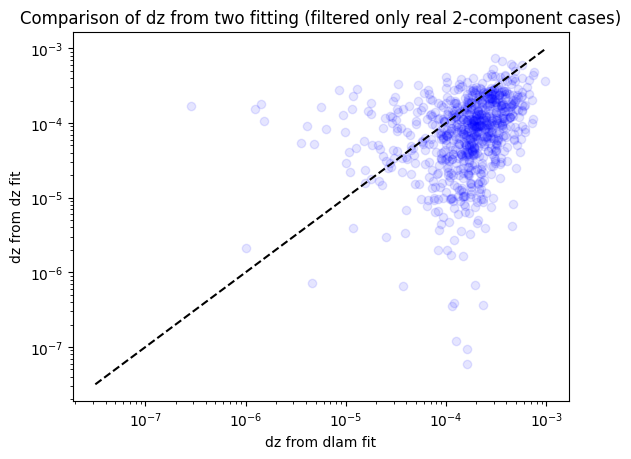

In [18]:
print(type(results))


chisqs = results



prefer_dlam = []
prefer_dz   = []

for i in range(len(chisqs)):
    # try:
        
    #     chisq_dlam, chisq_dz = chisqs[i]
        
    #     if (np.abs(chisq_dlam - chisq_dz) > 5) and (np.abs(chisq_dlam - chisq_dz) < 10):
    #         plt.scatter(chisq_dlam, chisq_dz, color='red', alpha=0.1)
    #         if chisq_dlam < chisq_dz:
    #             prefer_dlam.append(SPECTRA.targetID[i])
    #         else:
    #             prefer_dz.append(SPECTRA.targetID[i])
    #         # print(f'Index: {i}, ID: {SPECTRA.targetID[i]}, Chi-sq dlam: {chisq_dlam}, Chi-sq dz: {chisq_dz}')
    #     else:
    #         plt.scatter(chisq_dlam, chisq_dz, color='blue', alpha=0.1)
    # except:
    #     continue
    
    
    try:
        
        dlam_dz, dz_dz = chisqs[i]

        plt.scatter(dlam_dz, dz_dz, color='blue', alpha=0.1)
    except:
        continue

# draw y=x line
x = np.logspace(-7.5, -3, 100)
y = x
plt.plot(x, y, color='black', linestyle='--')

plt.xscale('log')
plt.yscale('log')


plt.ylabel('dz from dz fit')
plt.xlabel('dz from dlam fit')

plt.title('Comparison of dz from two fitting (filtered only real 2-component cases)')
plt.savefig('./figures/Nov26/dz_comparison.png')
plt.show()

In [13]:
# prefer_dlam_idx = [SPECTRA.id2index(k) for k in prefer_dlam]
# chisq_dlam_diff = []
# for i in prefer_dlam_idx:
#     chisq_dlam, chisq_dz = chisqs[i]
#     chisq_dlam_diff.append(chisq_dlam - chisq_dz)

# prefer_dz_idx   = [SPECTRA.id2index(k) for k in prefer_dz]
# chisq_dz_diff = []
# for i in prefer_dz_idx:
#     chisq_dlam, chisq_dz = chisqs[i]
#     chisq_dz_diff.append(chisq_dz - chisq_dlam)



In [14]:
# # top 10 differences
# top_10_dlam = sorted(chisq_dlam_diff)[:20]
# top_10_dz = sorted(chisq_dz_diff)[:20]
# print('Top 10 prefer dlam IDs:')
# for diff in top_10_dlam:
#     idx = chisq_dlam_diff.index(diff)
#     target_id = prefer_dlam[idx]
#     print(f'ID: {target_id}, Chi-sq difference: {diff}')
#     # print(image_link(SPECTRA.RA[idx], SPECTRA.DEC[idx]))
#     print(spectrum_link(target_id))
#     # image_link(SPECTRA.RA[SPECTRA.id2index(target_id)], SPECTRA.DEC[SPECTRA.id2index(target_id)], save_image=True, fname=f'./figures/Nov26/dlam_{target_id}.png')
    
# print('Top 10 prefer dz IDs:')
# for diff in top_10_dz:
#     idx = chisq_dz_diff.index(diff)
#     target_id = prefer_dz[idx]
#     print(f'ID: {target_id}, Chi-sq difference: {diff}')
#     # image_link(SPECTRA.RA[SPECTRA.id2index(target_id)], SPECTRA.DEC[SPECTRA.id2index(target_id)], save_image=True, fname=f'./figures/Nov26/dz_{target_id}.png')
#     # print(image_link(SPECTRA.RA[idx], SPECTRA.DEC[idx]))
#     print(spectrum_link(target_id))
